In [1]:
import numpy as np
from dataset import preprocess_pancreas_data

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/phate/__init__.py


In [2]:
FILE_NAME = "data/pancreas.h5ad"

adata_subsampled, x, adj = preprocess_pancreas_data(FILE_NAME)

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [5]:
import networkx as nx
import torch

G = nx.from_numpy_array(adj.numpy())
pos = nx.spring_layout(G, seed=42)
x_original = np.zeros((len(pos), 2))
for i, coord in pos.items():
    x_original[i] = coord

x_original = torch.tensor(x_original, dtype=torch.float32)

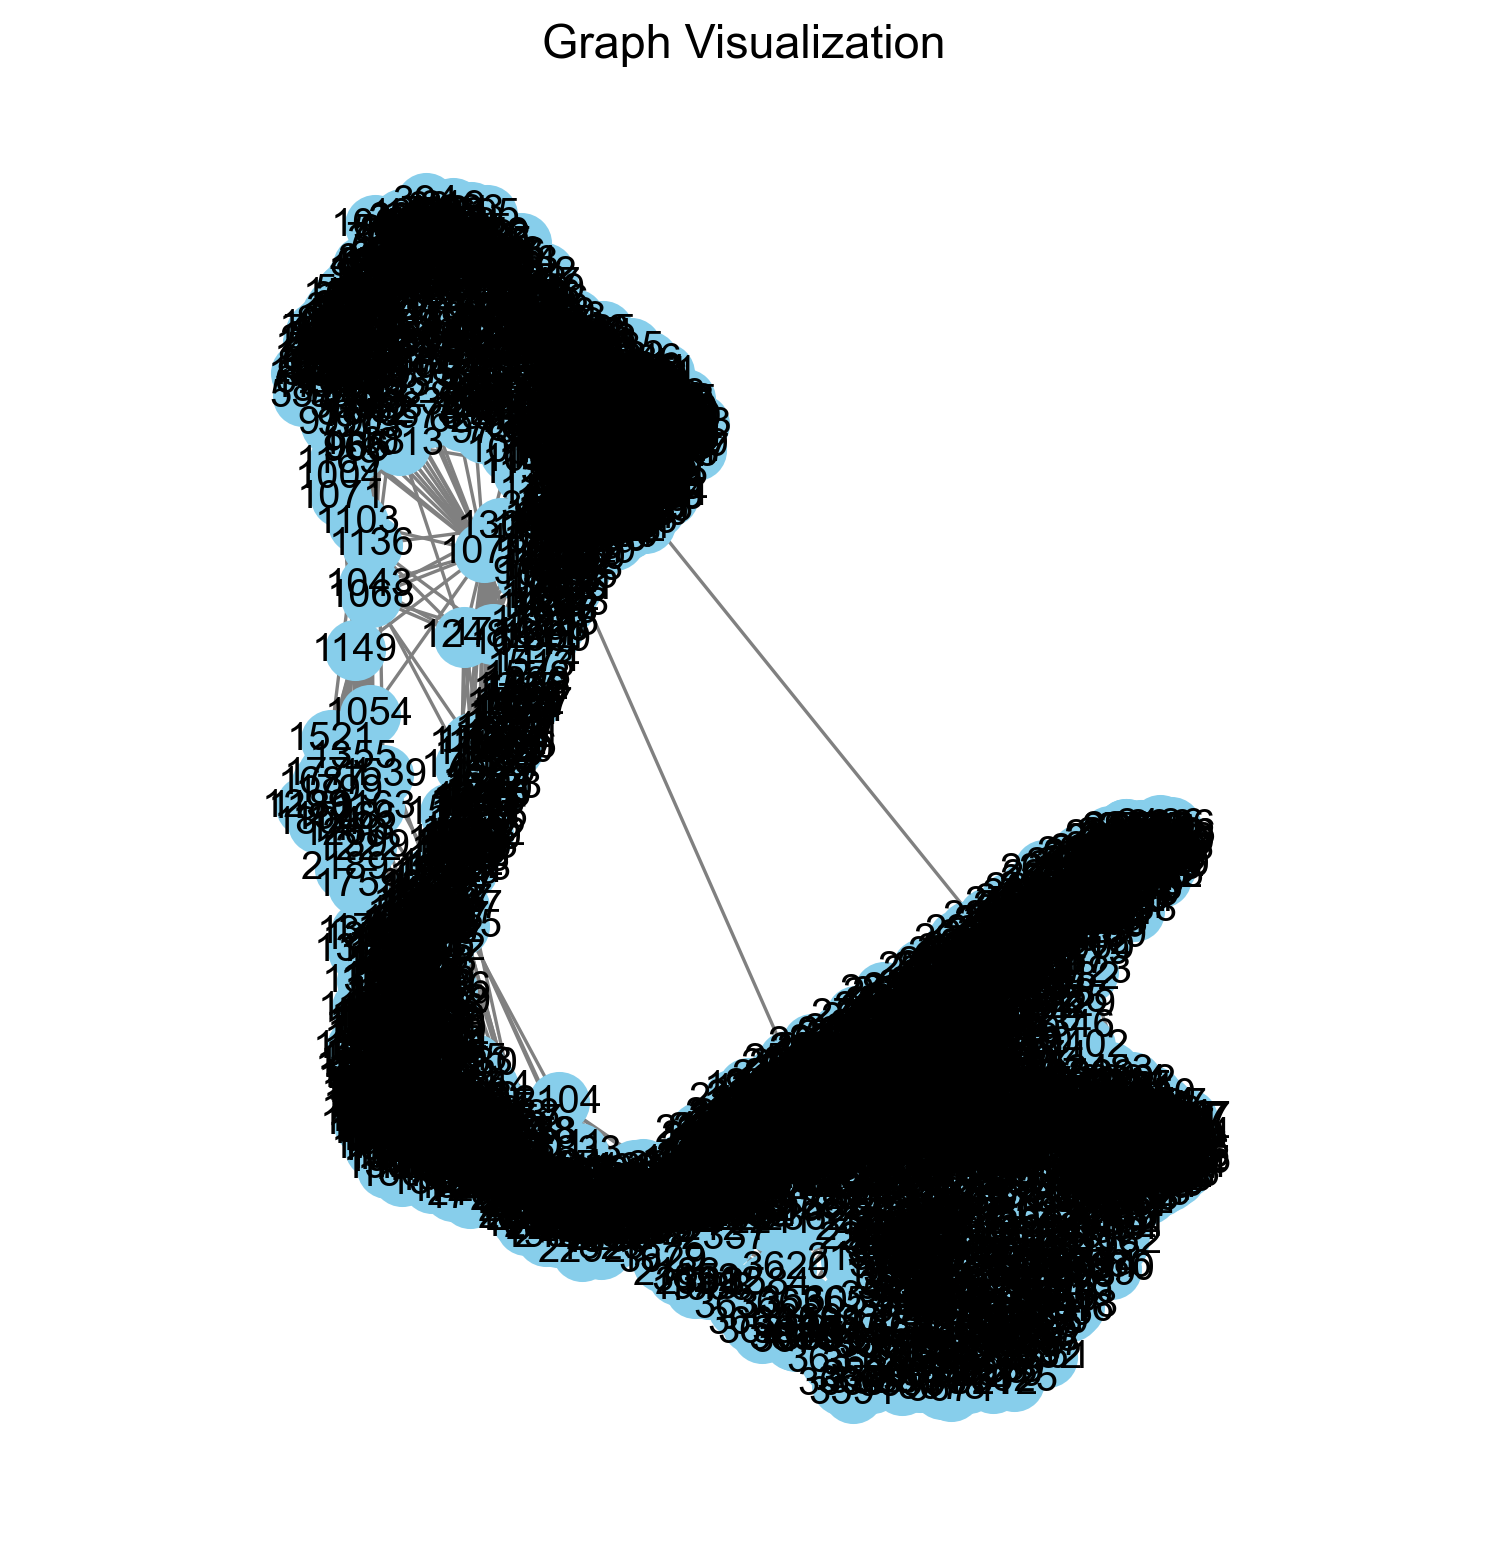

In [6]:
import matplotlib.pyplot as plt

# --- your existing code ---
G = nx.from_numpy_array(adj.numpy())
pos = nx.spring_layout(G, seed=42)

x_original = np.zeros((len(pos), 2))
for i, coord in pos.items():
    x_original[i] = coord

x_original = torch.tensor(x_original, dtype=torch.float32)
# --------------------------------

# Plotting
plt.figure(figsize=(6, 6))
nx.draw(
    G,
    pos={i: x_original[i].numpy() for i in range(len(x_original))},
    with_labels=True,
    node_size=300,
    edge_color="gray",
    node_color="skyblue"
)
plt.title("Graph Visualization")
plt.axis("equal")
plt.show()